# Clustering

**Solución:** https://colab.research.google.com/drive/1ccFKhL9MGeIsgKIP8oNySU1aKYiJ_11j?usp=sharing

**Challenge:** https://colab.research.google.com/drive/1outX-txjrv_AnMeY_uda9DIjRiSRMPol?usp=sharing

"If intelligence was a cake, unsupervised learning would be the cake, supervised learning would be the icing on the cake, and reinforcement learning would be the cherry on the cake" - Yann LeCun

Análisis de Agrupamientos: Proceso de particionamiento de un conjunto de datos (u observaciones) en subconjuntos. Cada subconjunto es un grupo o cluster.

* Los datos en un mismo cluster deben ser similares entre sí.
* Los datos de diferentes clusters deben ser diferentes entre sí.

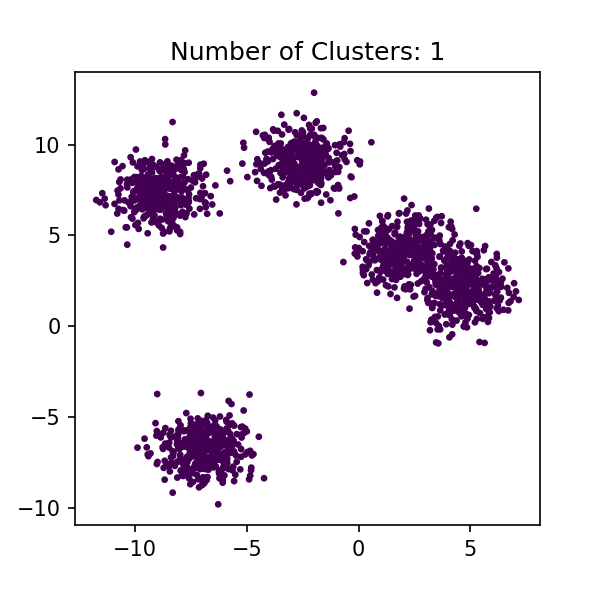

## K-Means

* Método que permite crear __clusters__ a partir de __datos numéricos__. El input del sistema son las mediciones numéricas de interés y los outputs son:
    * los centroides de los __clusters__ resultantes
    * la asignación de cada dato a un __cluster__ determinado.

* El __centroide__ es el punto que se encuentra en el centro de un __cluster__, (es la media de las coordenadas de todos los puntos de ese __cluster__).

* El número de centroides `k` es definido según convenga, para definir la distancia entre puntos y entre centroides se suele utilizar la distancia euclídeana.

* La __inercia__ del modelo es la métrica de rendimiento usada para saber donde colocar mejor los centroides, la inercia del modelo es la
distancia media cuadrática entre cada observación y su centroide más cercano.

La Inercia o __Within sum of squares__ se obtiene:

$WSS = \sum_{i = 1}^{K}\sum_{j = 1}^{n_i}{\mid x_{ij} - c_i\mid}^2$

donde:

- $K$, es el número de centroides
- $n_i$, es el número de elementos que pertenecen al centroide $i$
- $c_i$, centroide del cluster $i$
- $x_{ij}$, elemento $j$ del cluster $i$

### Implementación en Scikit-learn

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn import datasets
from pprint import pprint


In [53]:
iris_dat = datasets.load_iris()
# pprint(iris_dat)
iris = (pd.DataFrame(iris_dat.data)
       .rename(columns={0:'sepal_length',
                        1:'sepal_width',
                        2:'petal_length',
                        3:'petal_width'})
       .assign(species=iris_dat.target))



In [54]:

iris.head(20)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


#### Inspección visual (ternary plot)

In [55]:
fig = px.scatter_ternary(iris,
                         a = 'sepal_length',
                         b = 'petal_length',
                         c = 'sepal_width',
                         size = 'petal_width',
                         size_max = 12,
                         color = 'species',)
fig.show()

In [56]:
fig = px.scatter_3d(iris,
                         x = 'sepal_length',
                         y = 'petal_length',
                         z = 'sepal_width',
                         size = 'petal_width',
                         size_max = 12,
                         color = 'species',)
fig.show()

### Seleccionamos el numero de clusters

In [57]:
X = iris.drop('species', axis=1)
y= iris['species']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### `n_clusters`

De forma arbitraria seleccionamos el valor del hiperparametro `n_clusters=3`

In [59]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(X_train)

KMeans(n_clusters=3)

#### `inertia_`

Obtenemos la inercia del modelo

In [60]:
model.inertia_

56.5149574780059

También puede ser obtenido en su formato negativo bajo el protocolo de sklearn dónde "entre mas grande mejor"

In [61]:
model.score(X_train)

-56.514957478005904

#### `cluster_centers_`

In [62]:
model.cluster_centers_

array([[5.79545455, 2.69318182, 4.32727273, 1.39545455],
       [4.96451613, 3.37741935, 1.46451613, 0.2483871 ],
       [6.82      , 3.09333333, 5.68666667, 2.03333333]])

Obtenemos los centroides

In [63]:
centroides_df = pd.DataFrame(model.cluster_centers_).rename(columns={0:'sepal_length',
                                                                     1:'sepal_width',
                                                                     2:'petal_length',
                                                                     3:'petal_width'}
                                                            )


In [64]:
centroides_df

,sepal_length,sepal_width,petal_length,petal_width
0,5.795455,2.693182,4.327273,1.395455
1,4.964516,3.377419,1.464516,0.248387
2,6.820000,3.093333,5.686667,2.033333


In [65]:
fig = px.scatter_ternary(centroides_df,
                         a = 'sepal_length',
                         b = 'petal_length',
                         c = 'sepal_width',
                         color = 'petal_width',)
fig.show()

In [66]:
model.get_params(deep=True) #las iteraciones lo podemos modificar

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 'auto',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [67]:
model.get_metadata_routing()

{'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}

### Agregamos nuevas observaciones a nuestros clusters

a __K-MEANS__ todo lo que importa al asignar una observación
a un cluster es la distancia al centroide.

In [68]:
X_test

,sepal_length,sepal_width,petal_length,petal_width
73,6.1,2.8,4.7,1.2
18,5.7,3.8,1.7,0.3
118,7.7,2.6,6.9,2.3
78,6.0,2.9,4.5,1.5
76,6.8,2.8,4.8,1.4
31,5.4,3.4,1.5,0.4
64,5.6,2.9,3.6,1.3
141,6.9,3.1,5.1,2.3
68,6.2,2.2,4.5,1.5
82,5.8,2.7,3.9,1.2


In [69]:
cluster_results = model.predict(X_test)
cluster_results

array([0, 1, 2, 0, 0, 1, 0, 2, 0, 0, 2, 1, 1, 1, 1, 0, 2, 0, 0, 2, 1, 0,
       1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1], dtype=int32)

In [70]:
import plotly.graph_objects as go
#1. Creamos el gráfico
fig = px.scatter_3d(X_test,
                    x = 'sepal_length',
                    y = 'petal_length',
                    z = 'sepal_width',
                    size = 'petal_width',
                    size_max = 12,
                    color='petal_width')

#2. Añadimos los centroides como una capa encima
fig.add_trace(
    go.Scatter3d(
        x=centroides_df['sepal_length'],
        y=centroides_df['petal_length'],
        z=centroides_df['sepal_width'],
        mode='markers',
        marker=dict(
            size=7,
            color='black',
            symbol='diamond',
            line=dict(width=2, color='white')
            ),
            name='Centroides')
    )
fig.show()


In [71]:
X_test['cluster'] = cluster_results

In [72]:
X_test

,sepal_length,sepal_width,petal_length,petal_width,cluster
73,6.1,2.8,4.7,1.2,0
18,5.7,3.8,1.7,0.3,1
118,7.7,2.6,6.9,2.3,2
78,6.0,2.9,4.5,1.5,0
76,6.8,2.8,4.8,1.4,0
31,5.4,3.4,1.5,0.4,1
64,5.6,2.9,3.6,1.3,0
141,6.9,3.1,5.1,2.3,2
68,6.2,2.2,4.5,1.5,0
82,5.8,2.7,3.9,1.2,0


### Número optimo de clusters

#### Regla del codo

En general, no es fácil establecer el `k` optimo a priori y elegir el modelo con la menor inercia no es una buena idea ya que está regularmente disminuye a medida que aumentamos k, entonces La inercia no es una buena métrica de rendimiento.

In [73]:
inertias = {
    k: KMeans(n_clusters=k).fit(X_train).inertia_
    for k in range(1, 11)
}
inertias


{1: 455.9960000000001,
 2: 115.61213753106877,
 3: 56.5149574780059,
 4: 39.109485887096774,
 5: 32.73899710504549,
 6: 28.37721108550946,
 7: 27.917207478005878,
 8: 22.778649667647382,
 9: 19.15491479925304,
 10: 18.114727652464495}

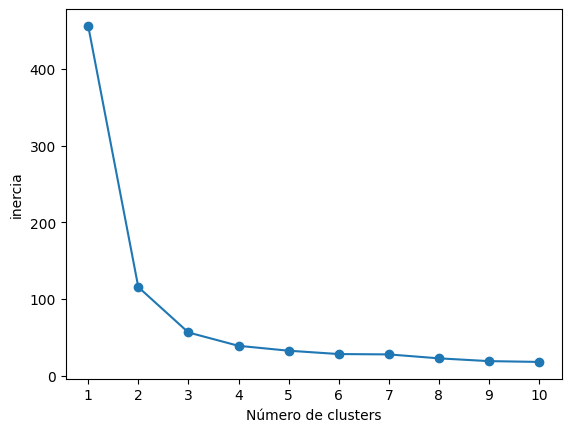

In [74]:
plt.plot(list(inertias.keys()),
         list(inertias.values()),'-o')
plt.xlabel('Número de clusters')
plt.ylabel('inercia')
plt.xticks(list(inertias.keys()))
plt.show()

A medida que aumentamos k, la inercia cae muy rápid. Esta curva tiene aproximadamente la forma de un brazo, y hay un "codo" en k = 3.

__SI NO TUVIERAMOS MAS CONOCIMIENTO DE LOS DATOS k = 3 SERíA UNA BUENA OPCIÓN__

* Cualquier valor antes del codo sería dramático
* Cualquier valor despues del codo no ayudaría mucho, ya que podríamos simplemente estar dividiendo grupos perfectamente buenos por la mitad sin una buena razón.

Entonces, __si no hay información que ayude a tomar una mejor decisión, el valor del codo es la mejor opción__.

__NOTA__: En general este proceso no es sencillo y hay que tener en cuenta que K-Means es muy sensible a diferencias en las varianzas de las variables y a variables con escalas muy distintas.

#### Silhouette

* Un enfoque más preciso (pero también computacionalmente más costoso) es utilizar el __Silhouette score__.

* El __Silhouette score__ es el silhouette medio sobre todas las instancias.

* El Silhouette de una instancia se define cómo $\frac{b-a}{max(a, b)}$ dónde:
    * $a$ es la distancia media a otras instancias en el mismo cluster (la distancia intra cluster media)
    * $b$ es la media de la distancia al cluster mas cercano (la distancia media a las instancias del siguiente cluster, definida como la que minimiza a $b$, excluyendo la distancia del propio cluster)

* El coeficiente Silouette está entre -1 y 1 esto se interpreta:
    * Entre mas cerca está de 1, significa que la instancia está bien dentro de su cluster y lejos de otros clusters
    * Entre mas cerca está de 0, significa que está muy cerca de una frontera entre clusters
    * Entre mas cerca está de -1 significa que la instancia ha sido asignada a un cluster donde no corresponde

##### Silhouette scores

In [75]:
from sklearn.metrics import silhouette_score
silhouette_scores = silhouette_score(X_test, cluster_results)
print(f'Silhouette Score for X_test: {silhouette_scores}')

Silhouette Score for X_test: 0.70918627959688


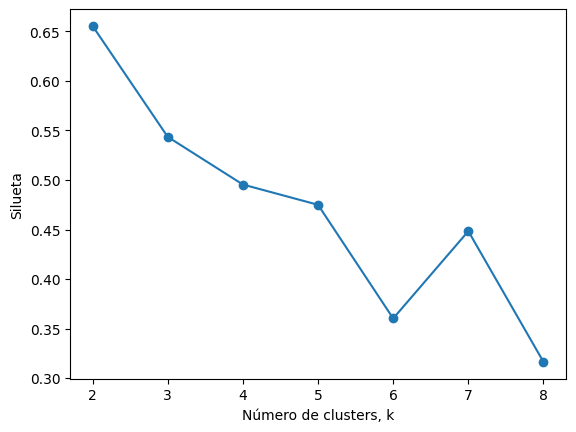

In [76]:
from sklearn.metrics import silhouette_score

silhouettes = {k: silhouette_score(X_train, KMeans(n_clusters=k).fit_predict(X_train)) for k in range(2, 9)}

plt.plot(list(silhouettes.keys()),
         list(silhouettes.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Silueta')
plt.xticks(list(silhouettes.keys()))
plt.show()

Está visualización es mas informativa que la gráfica del codo, en esta visualización observamos que `k=2` es un excelente `k`, pero `k=3` también es una excelente opción, estas opciones son mucho mejores que el resto, esta gráfica puede llegar a ser mas informativa que solo comparar inercias.

##### Silhouette diagrama

Una visualización aun mas informativa se obtiene cuando gráficamos el silhouette de cada instancia, agrupada por los clusters que los contiene y ordenada por sus valores.

Cada diagrama tiene forma de cuchillo por cluster:
* La altura del cuchillo significa la cantidad de instancias que contiene el cluster
* El ancho representa los coeficientes silhouette ordenados en el cluster (entre mas ancho mejor)
* La linea punteada representa el coeficiente silhouette medio

For n_clusters = 2, the average silhouette_score is: 0.6555
For n_clusters = 3, the average silhouette_score is: 0.5435
For n_clusters = 4, the average silhouette_score is: 0.4954
For n_clusters = 5, the average silhouette_score is: 0.4403
For n_clusters = 6, the average silhouette_score is: 0.4401
For n_clusters = 7, the average silhouette_score is: 0.4514
For n_clusters = 8, the average silhouette_score is: 0.3407


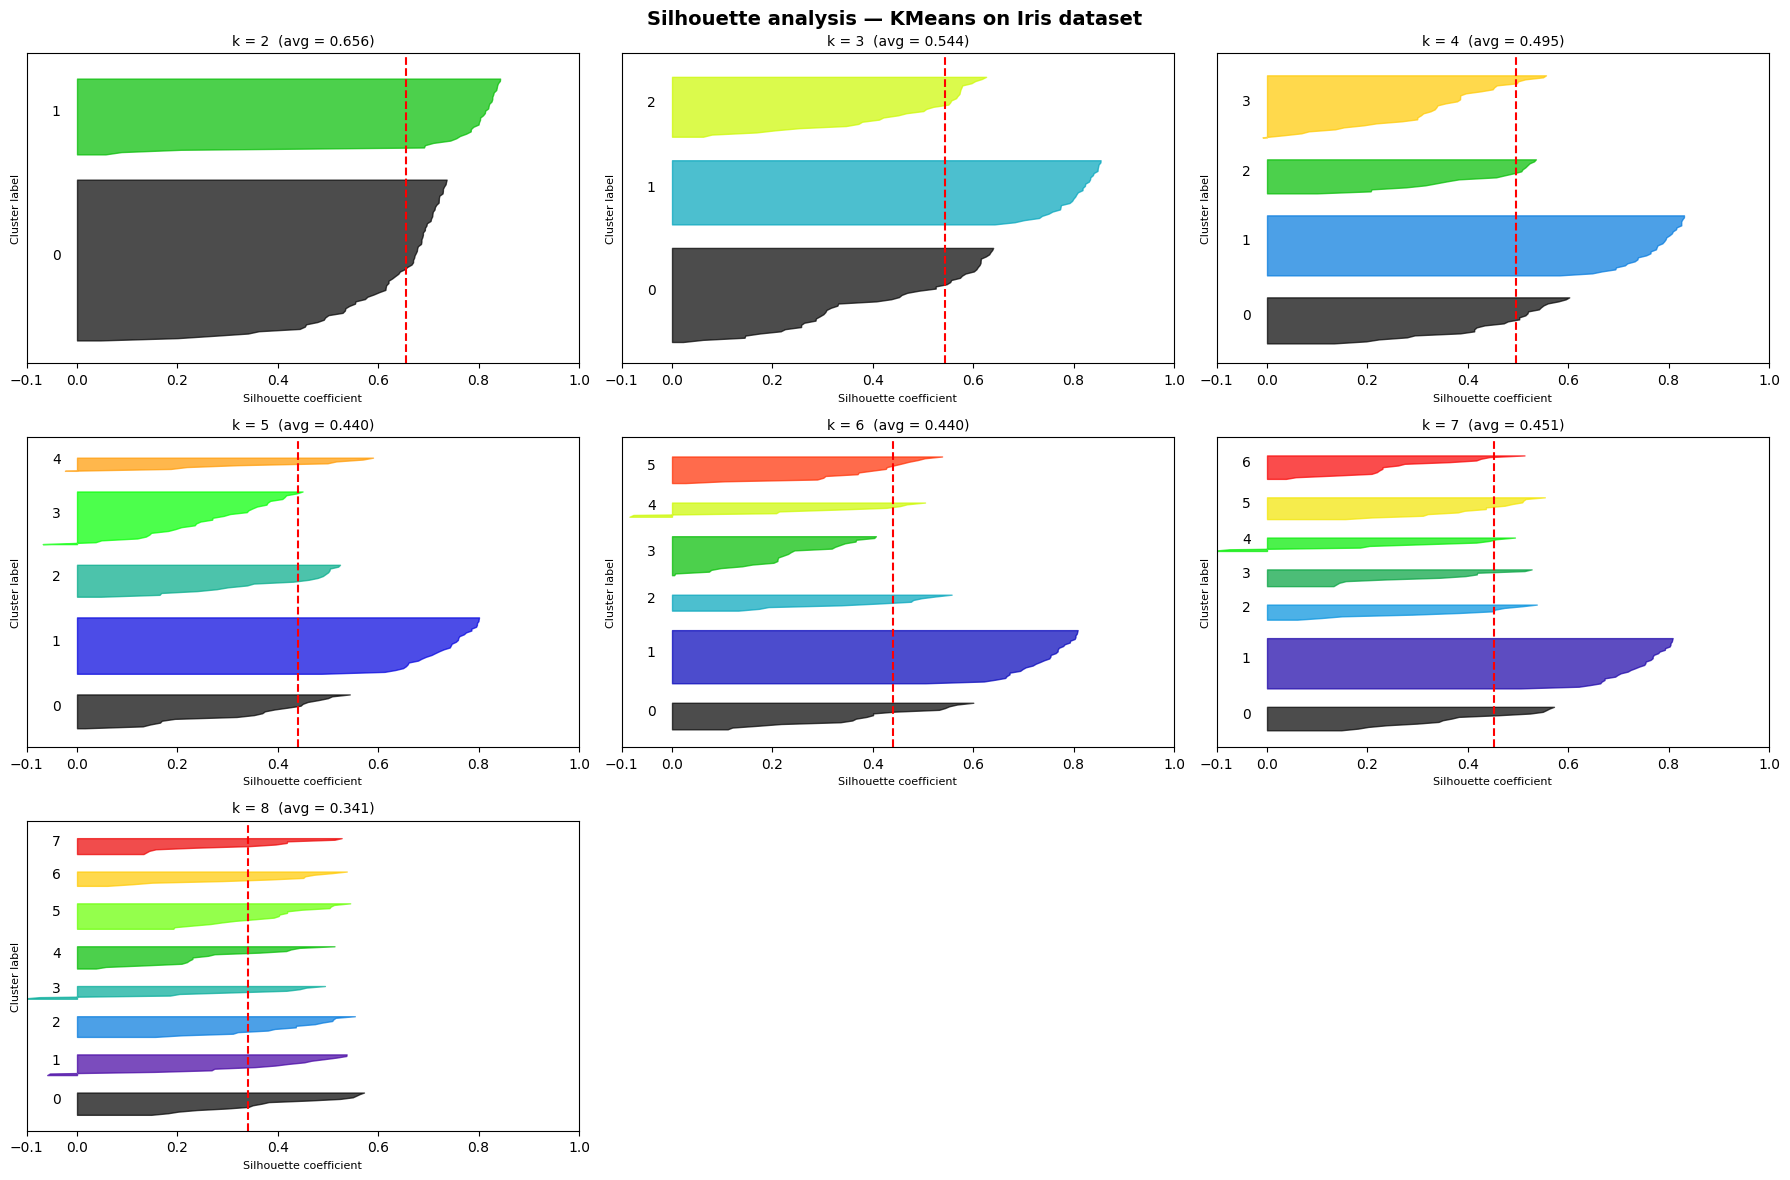

In [77]:
 from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

n_clusters_range = range(2, 9)
n_plots = len(n_clusters_range)
cols = 3
rows = (n_plots + cols - 1) // cols  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for idx, k in enumerate(n_clusters_range):
    ax = axes[idx]

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_train) + (k + 1) * 10])

    clusterer = KMeans(n_clusters=k, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_train)

    silhouette_avg = silhouette_score(X_train, cluster_labels)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_train, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"k = {k}  (avg = {silhouette_avg:.3f})", fontsize=10)
    ax.set_xlabel("Silhouette coefficient", fontsize=8)
    ax.set_ylabel("Cluster label", fontsize=8)
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# Ocultar subplots sobrantes (si el total no es múltiplo de cols)
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Silhouette analysis — KMeans on Iris dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Recomendaciones para K-means

* Normalizar las variables antes de hacer K-means, restar a cada variable su media y dividirla por la desviación típica

## Challenge

Considera los datos `creditcard.csv`. Los puedes encontrar [aquí](https://drive.google.com/file/d/1jqZ6--OOGk477xv_yxqyell8RBtlOXL8/view?usp=drive_link)

Como contexto, estos datos fueron obtenidos del siguiente enlace: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Consejo: Lee atentamente la descripción del dataset y el significado de las columnas en el enlace anterior.


## Realiza lo siguiente
1. Entrena un modelo con KMeans, recuerda separar la columna objetivo `Class` del resto de las columnas.
2. Identifica la mejor K utilizando el método del codo y el método de las siluetas.
3. Añade una columna llamada `cluster` etiquetando el set de prueba (30% de los datos).
4. Identifica el grupo al que pertenecen los datos cuyo `Class` es igual a 1. ¿Pertenecen a un solo grupo o a varios?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn import datasets
from pprint import pprint

In [2]:
df_credit_card = pd.read_csv('C:/Users/space/Downloads/creditcard.csv')
df_credit_card.head() 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df_credit_card['Class'].unique()

array([0, 1])

In [6]:
df_credit_card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df_credit_card.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
df_credit_card.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [12]:
df_credit_card.duplicated().sum()

np.int64(1081)

In [14]:
df_credit_card.drop_duplicates()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [45]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go


class_counts = df_credit_card['Class'].value_counts()
class_pct = df_credit_card['Class'].value_counts(normalize=True) * 100

print(f"Normal (0) : {class_counts[0]:,} → {class_pct[0]:.2f}%")
print(f"Fraude (1) : {class_counts[1]:,} → {class_pct[1]:.2f}%")


labels = ['Normal', 'Fraude']
values = [class_counts.get(0, 0), class_counts.get(1, 0)]
colors = ['steelblue', 'crimson']


fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "xy"}, {"type": "domain"}]],
    subplot_titles=("Distribución de clase (Count)", "Distribución de clase (Porcentaje)")
)


bar_fig = px.bar(
    x=labels, y=values,
    color=labels,
    color_discrete_sequence=colors,
    text=[f"{v:,}" for v in values]
)

for trace in bar_fig.data:
    fig.add_trace(trace, row=1, col=1)
fig.update_traces(textposition='outside', selector=dict(type='bar'))


pie_fig = px.pie(
    names=labels, values=values,
    color=labels,
    color_discrete_sequence=colors
)
fig.add_trace(pie_fig.data[0], row=1, col=2)
fig.update_traces(
    textinfo='percent+label',
    texttemplate='%{label}<br>%{percent:.2%}',
    textposition='outside',
    pull=[0, 0.12],
    automargin=True,
    selector=dict(type='pie')
)


fig.update_layout(
    title_text='Alto desbalance en el data set',
    title_x=0.5,
    title_y=0.95,
    title_font=dict(size=18),
    showlegend=False,
    height=540,
    width=1000,
    margin=dict(t=130, b=60, l=60, r=60)
)
fig.update_yaxes(title_text="Count", row=1, col=1)

for ann in fig.layout.annotations:
    ann.y = 1.08
    ann.font.size = 14

fig.show()

Normal (0) : 284,315 → 99.83%
Fraude (1) : 492 → 0.17%


In [19]:
X = df_credit_card.drop('Class', axis=1)
y= df_credit_card['Class']



In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [44]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

before_counts = y_train.value_counts()
after_counts = y_train_sm.value_counts()

labels = ['Normal', 'Fraude']
before_values = [before_counts.get(0, 0), before_counts.get(1, 0)]
after_values = [after_counts.get(0, 0), after_counts.get(1, 0)]
colors = ['blue', 'yellow']

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Antes", "Después")
)

fig.add_trace(
    go.Bar(
        x=labels,
        y=before_values,
        marker=dict(color=colors, line=dict(color='black', width=1)),
        text=[f"{v:,}" for v in before_values],
        textposition='outside',
        textfont=dict(size=12),
        showlegend=False
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=labels,
        y=after_values,
        marker=dict(color=colors, line=dict(color='black', width=1)),
        text=[f"{v:,}" for v in after_values],
        textposition='outside',
        textfont=dict(size=12),
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    title_text='SMOTE: Balanceo del Dataset',
    title_x=0.5,
    title_font=dict(size=18, family='Arial Black'),
    height=500,
    width=1000,
    margin=dict(t=100, b=60, l=60, r=40),
    bargap=0.3
)

fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Count", row=1, col=2)

for ann in fig.layout.annotations:
    ann.font.size = 14
    ann.y = 1.05

fig.show()

In [21]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(X_train)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [22]:
model.inertia_

44065107481385.76

In [23]:
model.score(X_train)

-44065107481385.766

In [24]:
model.cluster_centers_

array([[ 1.42000245e+05,  2.73483951e-01, -6.12821934e-02,
        -7.22281894e-01, -1.67086311e-01,  2.76323792e-01,
        -8.75914913e-02,  1.24514713e-01, -6.13380422e-02,
         1.60841699e-03,  4.21709260e-02, -2.64564639e-01,
         9.52318023e-02, -7.24925806e-02, -9.96368578e-02,
        -2.00859843e-01,  1.56375758e-02, -5.74498276e-02,
         7.72884301e-02,  2.84896861e-02, -4.50763310e-02,
         4.63947799e-02,  1.31734815e-01,  3.23794533e-02,
        -1.17635206e-02, -1.34929563e-01, -2.45973995e-02,
        -2.88391720e-03, -3.31088000e-03,  8.91105103e+01],
       [ 3.52392505e+04, -2.49600676e-01, -2.26373263e-02,
         6.84034097e-01,  1.67235453e-01, -2.68809492e-01,
         9.81661418e-02, -1.11194670e-01,  5.68441111e-02,
         1.60681096e-02, -3.61940775e-02,  2.96674136e-01,
        -1.75233158e-01,  6.84845656e-02,  9.64026142e-02,
         1.57140019e-01, -1.10964201e-02,  8.20975918e-02,
        -9.46765342e-02, -2.55120706e-02,  4.60409410e-

In [25]:
columnas = X.columns
nombres_columnas = {i: col for i, col in enumerate(columnas)}
centroides_df = pd.DataFrame(model.cluster_centers_).rename(columns=nombres_columnas)

In [26]:
centroides_df 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,142000.244900,0.273484,-0.061282,-0.722282,-0.167086,0.276324,-0.087591,0.124515,-0.061338,0.001608,...,-0.045076,0.046395,0.131735,0.032379,-0.011764,-0.134930,-0.024597,-0.002884,-0.003311,89.110510
1,35239.250525,-0.249601,-0.022637,0.684034,0.167235,-0.268809,0.098166,-0.111195,0.056844,0.016068,...,0.046041,-0.027313,-0.107935,-0.037375,0.005309,0.133993,0.024643,0.002237,0.003638,96.939508
2,73792.671385,-0.207389,0.104653,0.520091,0.107409,-0.188566,0.042823,-0.085371,0.040713,-0.017287,...,0.029533,-0.048222,-0.114038,-0.017875,0.011206,0.087329,0.018589,0.000531,0.001850,81.367754


In [28]:
model.get_params(deep=True)

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 'auto',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [29]:
model.get_metadata_routing()

{'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}

In [30]:
X_test

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,-1.514923,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,0.506044,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.212877,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,-0.244633,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.255293,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180795,124702.0,-0.673320,1.823100,-2.152665,-1.051308,1.822568,1.319646,-0.228012,-1.743339,-0.665095,...,-0.574493,2.292603,-0.929823,0.561185,2.970343,-0.632171,0.095316,0.031770,0.093565,3.99
259979,159354.0,2.125553,-0.065046,-1.537467,0.125578,0.500319,-0.359530,0.124248,-0.201678,0.551045,...,-0.157091,-0.342157,-0.878330,0.281129,0.035931,-0.173013,0.207555,-0.075438,-0.060078,1.79
21885,31911.0,0.746800,-1.028053,1.127833,1.631418,-1.193487,0.946088,-0.857322,0.480905,1.662617,...,0.061614,0.073226,0.058198,-0.235697,-0.457910,0.328226,-0.219767,0.058352,0.058441,195.60
217812,141043.0,2.080547,0.167780,-1.722107,0.403323,0.451991,-0.848388,0.190703,-0.239152,0.481197,...,-0.148994,-0.367406,-0.945073,0.332659,0.484916,-0.246959,0.174693,-0.061887,-0.030910,0.89


In [31]:
cluster_results = model.predict(X_test)
cluster_results

array([1, 1, 1, ..., 1, 0, 2], shape=(85443,), dtype=int32)

In [32]:
X_test['cluster'] = cluster_results

In [33]:
X_test

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,cluster
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,...,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,...,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,1
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,...,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,1
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,...,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,...,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180795,124702.0,-0.673320,1.823100,-2.152665,-1.051308,1.822568,1.319646,-0.228012,-1.743339,-0.665095,...,2.292603,-0.929823,0.561185,2.970343,-0.632171,0.095316,0.031770,0.093565,3.99,0
259979,159354.0,2.125553,-0.065046,-1.537467,0.125578,0.500319,-0.359530,0.124248,-0.201678,0.551045,...,-0.342157,-0.878330,0.281129,0.035931,-0.173013,0.207555,-0.075438,-0.060078,1.79,0
21885,31911.0,0.746800,-1.028053,1.127833,1.631418,-1.193487,0.946088,-0.857322,0.480905,1.662617,...,0.073226,0.058198,-0.235697,-0.457910,0.328226,-0.219767,0.058352,0.058441,195.60,1
217812,141043.0,2.080547,0.167780,-1.722107,0.403323,0.451991,-0.848388,0.190703,-0.239152,0.481197,...,-0.367406,-0.945073,0.332659,0.484916,-0.246959,0.174693,-0.061887,-0.030910,0.89,0


In [34]:
inertias = {
    k: KMeans(n_clusters=k).fit(X_train).inertia_
    for k in range(1, 11)
}
inertias


{1: 449339241676628.8,
 2: 82802193285348.56,
 3: 44065033080880.67,
 4: 24968927588156.383,
 5: 16574748373841.447,
 6: 12191581230734.654,
 7: 8312627257700.05,
 8: 6616747411041.801,
 9: 5251481512602.322,
 10: 4283745512492.666}

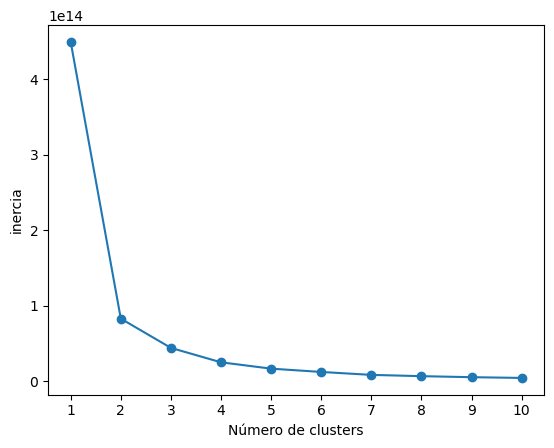

In [35]:
plt.plot(list(inertias.keys()),
         list(inertias.values()),'-o')
plt.xlabel('Número de clusters')
plt.ylabel('inercia')
plt.xticks(list(inertias.keys()))
plt.show()

In [36]:
from sklearn.metrics import silhouette_score
silhouette_scores = silhouette_score(X_test, cluster_results)
print(f'Silhouette Score for X_test: {silhouette_scores}')

Silhouette Score for X_test: 0.6314183744147671


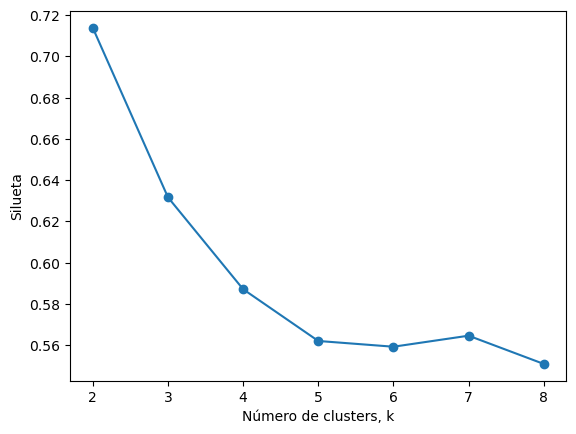

In [37]:
from sklearn.metrics import silhouette_score

silhouettes = {k: silhouette_score(X_train, KMeans(n_clusters=k).fit_predict(X_train)) for k in range(2, 9)}

plt.plot(list(silhouettes.keys()),
         list(silhouettes.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Silueta')
plt.xticks(list(silhouettes.keys()))
plt.show()

For n_clusters = 2, the average silhouette_score is: 0.7138
For n_clusters = 3, the average silhouette_score is: 0.6315
For n_clusters = 4, the average silhouette_score is: 0.5872
For n_clusters = 5, the average silhouette_score is: 0.5677
For n_clusters = 6, the average silhouette_score is: 0.5771
For n_clusters = 7, the average silhouette_score is: 0.5645
For n_clusters = 8, the average silhouette_score is: 0.5510


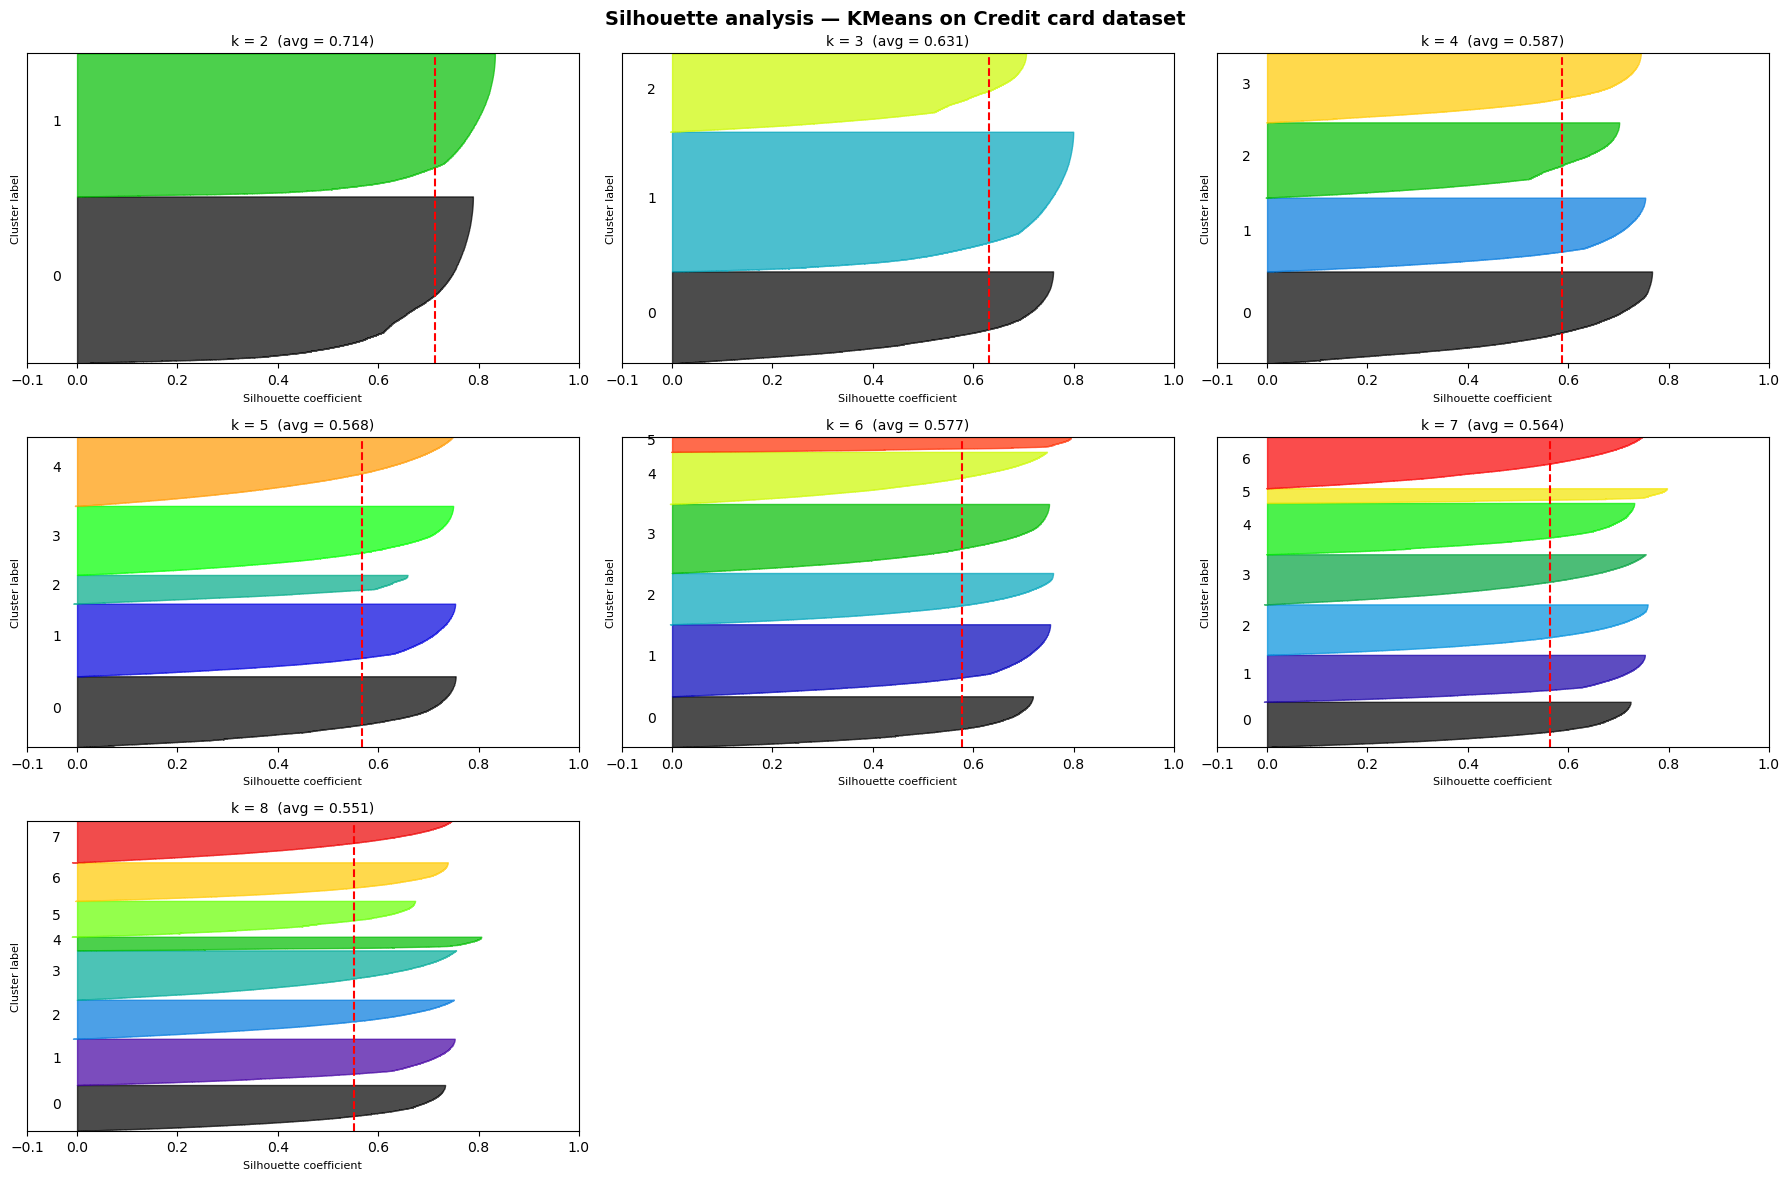

In [38]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

n_clusters_range = range(2, 9)
n_plots = len(n_clusters_range)
cols = 3
rows = (n_plots + cols - 1) // cols  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for idx, k in enumerate(n_clusters_range):
    ax = axes[idx]

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_train) + (k + 1) * 10])

    clusterer = KMeans(n_clusters=k, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_train)

    silhouette_avg = silhouette_score(X_train, cluster_labels)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_train, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"k = {k}  (avg = {silhouette_avg:.3f})", fontsize=10)
    ax.set_xlabel("Silhouette coefficient", fontsize=8)
    ax.set_ylabel("Cluster label", fontsize=8)
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# Ocultar subplots sobrantes (si el total no es múltiplo de cols)
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Silhouette analysis — KMeans on Credit card dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

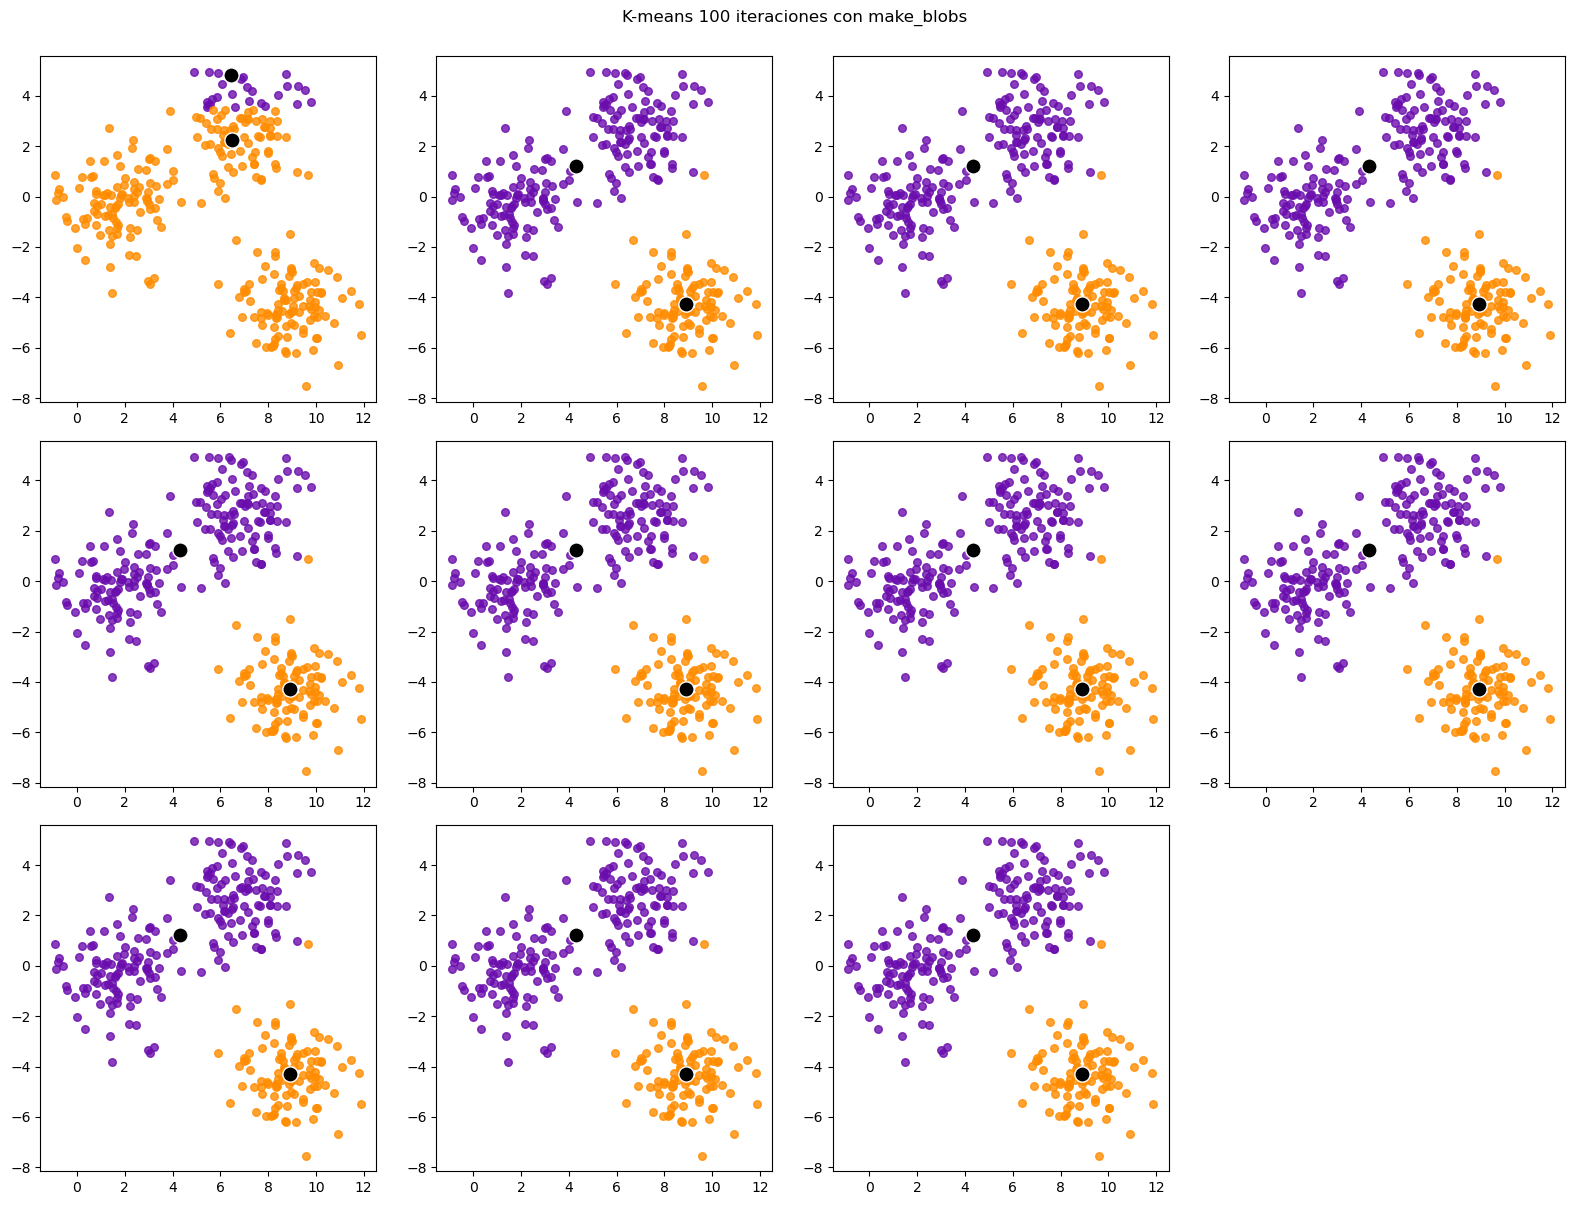

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from matplotlib.colors import ListedColormap

# 1. Genera los datos sintéticos igual que en la imagen
np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)
X = X * 2 + [5, -6]

k = 2
max_iter = 100 # ahora 100
colors = ['#6a0dad', '#ff8c00', '#ffff00'] # morado, naranja, amarillo
cmap = ListedColormap(colors)

# 2. Inicializa centroides aleatorios como en la imagen
np.random.seed(0)
centroids = X[np.random.choice(len(X), k, replace=False)]

# 3. Solo graficamos cada 10 iteraciones: 0, 10, 20,..., 100
plot_iters = list(range(0, max_iter + 1, 10)) # 11 plots
cols = 4
rows = (len(plot_iters) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

for it in range(max_iter + 1):
    # Asigna cada punto al centroide más cercano
    distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = np.argmin(distances, axis=1)

    # Solo pinta si toca
    if it in plot_iters:
        plot_idx = plot_iters.index(it)
        ax = axes[plot_idx]

        # Pinta puntos por cluster
        for c in range(k):
            ax.scatter(X[labels==c, 0], X[labels==c, 1],
                       c=colors[c], s=30, alpha=0.8, label=str(c))

        # Pinta centroides
        ax.scatter(centroids[:, 0], centroids[:, 1],
                   c='black', s=120, edgecolor='white', linewidth=1, zorder=10)

        
    # Actualiza centroides para la siguiente iteración
    new_centroids = np.array([
        X[labels==c].mean(axis=0) if np.any(labels==c) else centroids[c]
        for c in range(k)
    ])
    centroids = new_centroids

# Apaga subplots vacíos
for j in range(len(plot_iters), len(axes)):
    axes[j].axis('off')

plt.suptitle('K-means 100 iteraciones con make_blobs', y=1.0)
plt.tight_layout()
plt.show()

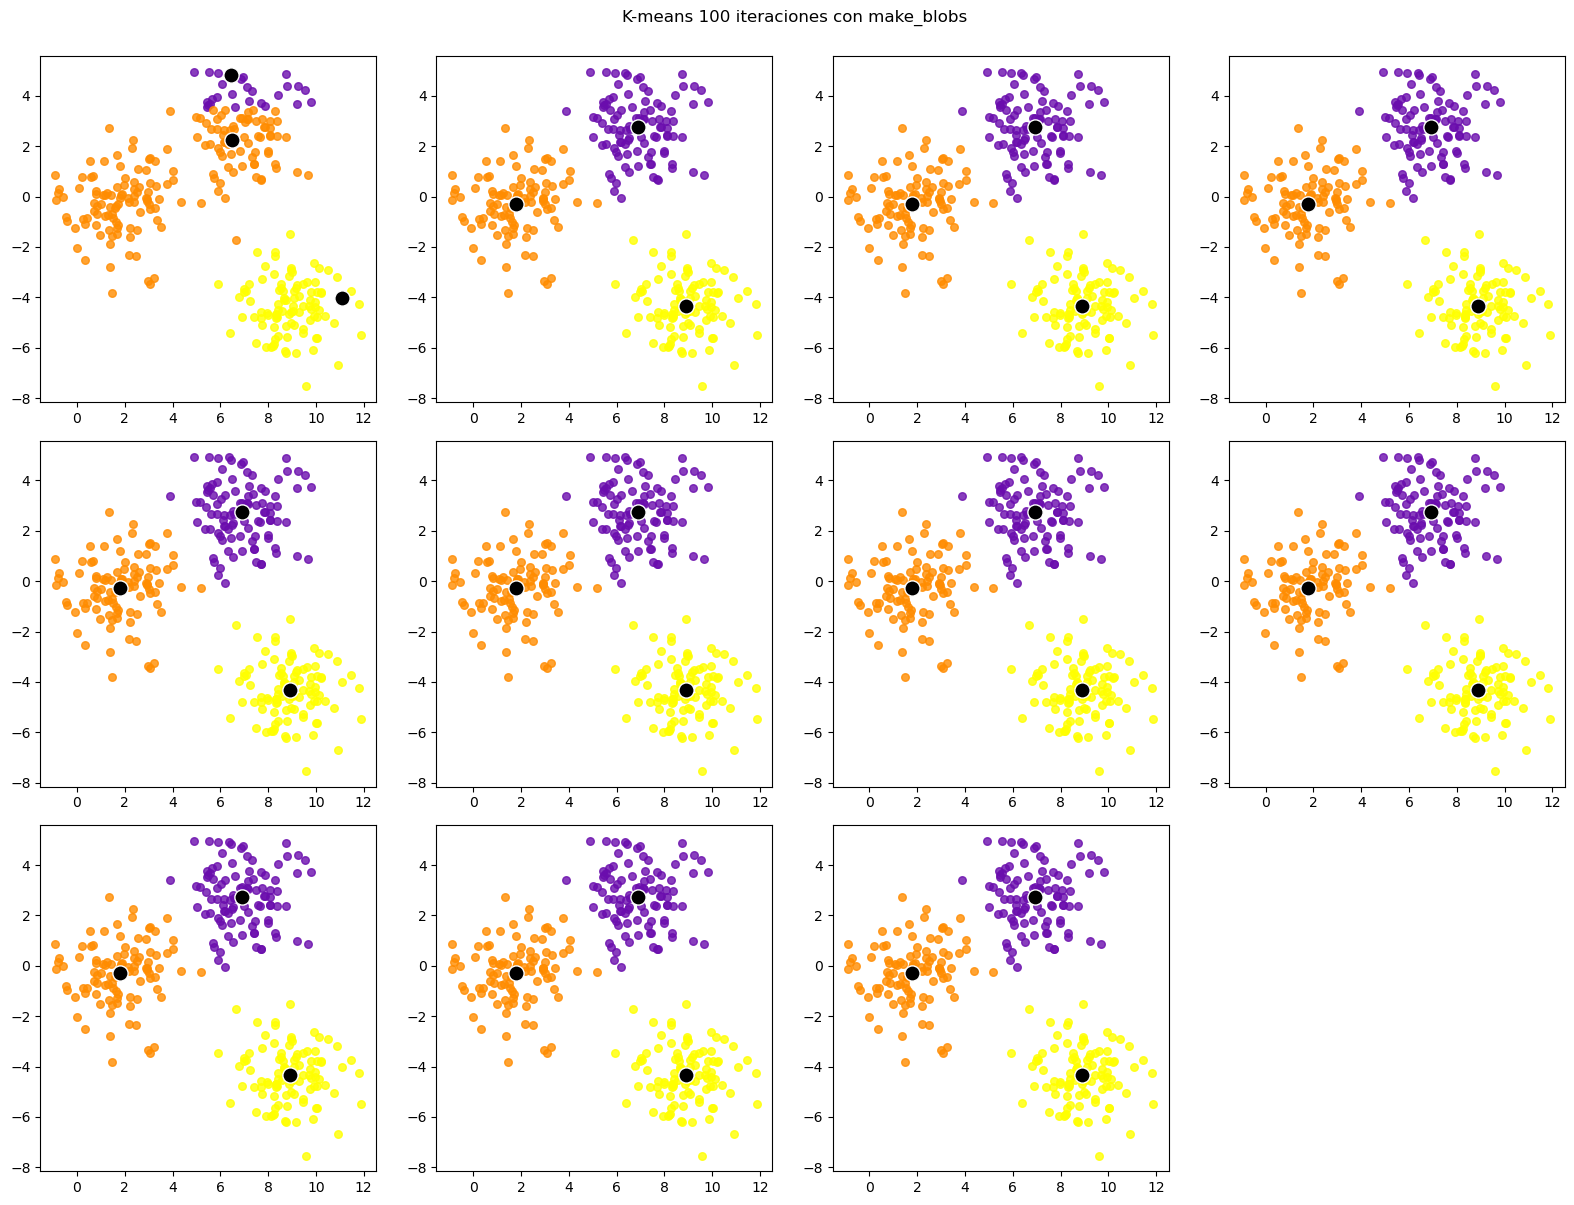

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from matplotlib.colors import ListedColormap

# 1. Genera los datos sintéticos igual que en la imagen
np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)
X = X * 2 + [5, -6]

k = 3
max_iter = 100 # ahora 100
colors = ['#6a0dad', '#ff8c00', '#ffff00'] # morado, naranja, amarillo
cmap = ListedColormap(colors)

# 2. Inicializa centroides aleatorios como en la imagen
np.random.seed(0)
centroids = X[np.random.choice(len(X), k, replace=False)]

# 3. Solo graficamos cada 10 iteraciones: 0, 10, 20,..., 100
plot_iters = list(range(0, max_iter + 1, 10)) # 11 plots
cols = 4
rows = (len(plot_iters) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

for it in range(max_iter + 1):
    # Asigna cada punto al centroide más cercano
    distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = np.argmin(distances, axis=1)

    # Solo pinta si toca
    if it in plot_iters:
        plot_idx = plot_iters.index(it)
        ax = axes[plot_idx]

        # Pinta puntos por cluster
        for c in range(k):
            ax.scatter(X[labels==c, 0], X[labels==c, 1],
                       c=colors[c], s=30, alpha=0.8, label=str(c))

        # Pinta centroides
        ax.scatter(centroids[:, 0], centroids[:, 1],
                   c='black', s=120, edgecolor='white', linewidth=1, zorder=10)

        
    # Actualiza centroides para la siguiente iteración
    new_centroids = np.array([
        X[labels==c].mean(axis=0) if np.any(labels==c) else centroids[c]
        for c in range(k)
    ])
    centroids = new_centroids

# Apaga subplots vacíos
for j in range(len(plot_iters), len(axes)):
    axes[j].axis('off')

plt.suptitle('K-means 100 iteraciones con make_blobs', y=1.0)
plt.tight_layout()
plt.show()